# Analyze Intrinsic Metrics

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../../scripts/")
from analysis.model_info import MODEL_INFORMATION
%load_ext autoreload
%autoreload 2

In [2]:
df = pd.read_json(
    "data/compiled_intrinsic_metrics.jsonl",
    orient="records",
    lines=True,
)

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler


def calculate_quality_score(df):
    """Calculate an aggregate quality score from intrinsic metrics using z-score normalization.

    Each metric is standardized (mean=0, std=1) and then averaged. This approach:
    - Handles extreme outliers automatically
    - Gives equal weight to each metric in terms of variance
    - Incorporates all 4 metrics: prompts_distinct_ri, responses_distinct_ri,
      rubric_score, and perplexity (log-transformed and inverted)

    df (pd.DataFrame): DataFrame with columns: prompts_distinct_ri,
        responses_distinct_ri, rubric_score, perplexity

    RETURNS (pd.Series): Quality scores for each row (higher is better)
    """
    data = np.column_stack(
        [
            df["prompts_distinct_ri"],
            df["responses_distinct_ri"],
            df["rubric_score"],
            -np.log1p(df["perplexity"]),
        ]
    )

    # Standardize and average
    scaler = StandardScaler()
    normalized = scaler.fit_transform(data)
    quality_score = normalized.mean(axis=1)

    return quality_score

In [4]:
# Calculate quality score
df["quality_score"] = calculate_quality_score(df)

# Show top models by quality score
df[
    [
        "language",
        "model",
        "quality_score",
        "rubric_score",
        "responses_distinct_ri",
        "prompts_distinct_ri",
        "perplexity",
    ]
].sort_values("quality_score", ascending=False)

,language,model,quality_score,rubric_score,responses_distinct_ri,prompts_distinct_ri,perplexity
33,es,google/gemma-3-27b-it,0.992086,4.2662,0.902532,0.767534,4.297941
32,es,google/gemma-3-12b-it,0.863697,4.1926,0.895211,0.762933,4.141318
22,de,google/gemma-3-12b-it,0.811696,4.2028,0.898606,0.751085,4.060759
24,de,google/gemma-3-4b-it,0.718975,4.1030,0.897925,0.744396,3.963183
23,de,google/gemma-3-27b-it,0.675951,4.2601,0.897766,0.730997,3.960716
54,ja,google/gemma-3-4b-it,0.660319,3.6565,0.874626,0.793631,6.453117
34,es,google/gemma-3-4b-it,0.649920,4.0214,0.887210,0.754137,4.515353
52,ja,google/gemma-3-12b-it,0.622305,4.0174,0.884813,0.756483,5.779713
31,es,cohere-command-a,0.590904,4.3357,0.883901,0.732682,3.773412
21,de,cohere-command-a,0.585925,4.2353,0.889303,0.729790,3.586949


In [5]:
from analysis import plot_theme

plot_params = plot_theme.PLOT_PARAMS.copy()
plt.rcParams.update(plot_params)

### Component contributions to quality score

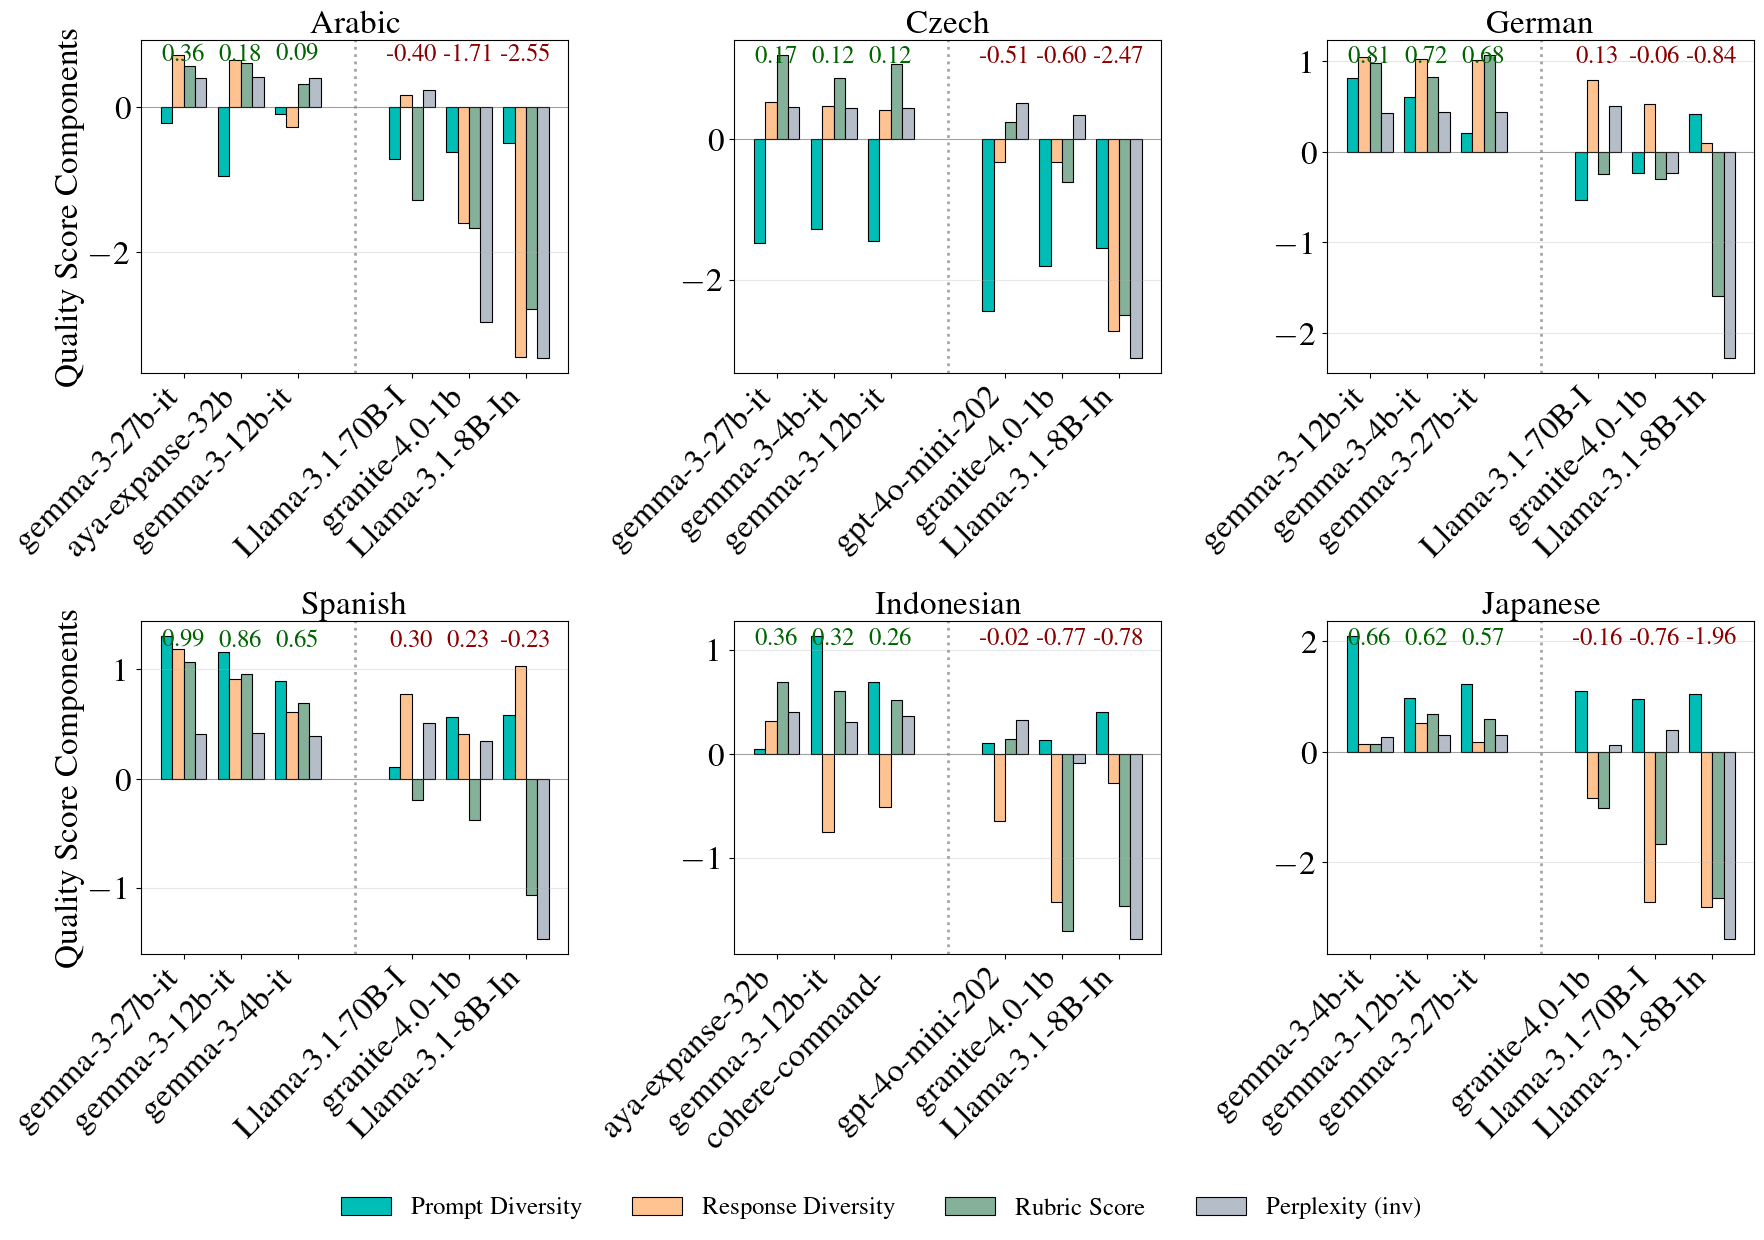

In [6]:
from analysis.plot_theme import COLORS

df_sorted = df.sort_values("quality_score", ascending=False).reset_index(drop=True)

data = np.column_stack(
    [
        df_sorted["prompts_distinct_ri"],
        df_sorted["responses_distinct_ri"],
        df_sorted["rubric_score"],
        -np.log1p(df_sorted["perplexity"]),
    ]
)

scaler = StandardScaler()
normalized = scaler.fit_transform(data)

df_components = pd.DataFrame(
    normalized,
    columns=[
        "Prompt Diversity",
        "Response Diversity",
        "Rubric Score",
        "Perplexity (inv)",
    ],
)
df_components["model"] = df_sorted["model"].values
df_components["language"] = df_sorted["language"].values
df_components["quality_score"] = df_sorted["quality_score"].values

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

languages = ["ar", "cs", "de", "es", "id", "ja"]
language_names = {
    "ar": "Arabic",
    "cs": "Czech",
    "de": "German",
    "es": "Spanish",
    "id": "Indonesian",
    "ja": "Japanese",
}
metrics = ["Prompt Diversity", "Response Diversity", "Rubric Score", "Perplexity (inv)"]
colors = [
    COLORS["warm_blue"],
    COLORS["warm_crest"],
    COLORS["heritage"],
    COLORS["slate"],
]

for idx, (lang, ax) in enumerate(zip(languages, axes)):
    lang_df = df_components[df_components["language"] == lang].sort_values(
        "quality_score", ascending=False
    )
    selected = pd.concat([lang_df.head(3), lang_df.tail(3)]).reset_index(drop=True)

    x = np.array([0, 1, 2, 4, 5, 6])
    width = 0.2

    for i, (metric, color) in enumerate(zip(metrics, colors)):
        offset = (i - 1.5) * width
        ax.bar(
            x + offset,
            selected[metric],
            width,
            label=metric if idx == 5 else "",
            color=color,
            edgecolor="black",
            linewidth=0.8,
        )

    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8, alpha=0.3)
    ax.axvline(x=3, color="gray", linestyle=":", linewidth=2, alpha=0.7)

    for i, (x_pos, row) in enumerate(zip(x, selected.iterrows())):
        quality = row[1]["quality_score"]
        if i < 3:
            ax.text(
                x_pos,
                ax.get_ylim()[1] * 0.95,
                f"{quality:.2f}",
                ha="center",
                va="top",
                fontsize=18,
                color="darkgreen",
                weight="bold",
            )
        else:
            ax.text(
                x_pos,
                ax.get_ylim()[1] * 0.95,
                f"{quality:.2f}",
                ha="center",
                va="top",
                fontsize=18,
                color="darkred",
                weight="bold",
            )

    ax.set_title(language_names[lang])
    ax.set_xticks(x)
    ax.set_xticklabels(
        [row["model"].split("/")[-1][:15] for _, row in selected.iterrows()],
        rotation=45,
        ha="right",
    )
    if idx % 3 == 0:
        ax.set_ylabel("Quality Score Components")
    ax.grid(True, alpha=0.3, axis="y")

fig.legend(
    *axes[5].get_legend_handles_labels(),
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=4,
    fontsize=18,
)

plt.tight_layout()
fig.savefig("figures/component_contributions_by_language.png", dpi=300, bbox_inches="tight")  # fmt: skip

plt.show()

### Does model size correlate with intrinsic data quality?

Loading model family logos...
Failed to load image from https://cdn.prod.website-files.com/62902d243ad8aad5c0fb3e24/65d2db1ef79bc75bd0e6b41e_For-Cohere_-Logo-Assets-66.svg: HTTP Error 403: Forbidden
Failed to load image from https://cdn.prod.website-files.com/62902d243ad8aad5c0fb3e24/65d2db1ef79bc75bd0e6b41e_For-Cohere_-Logo-Assets-66.svg: HTTP Error 403: Forbidden
Failed to load image from https://www.gstatic.com/lamda/images/gemini_sparkle_v002_advanced_1743d7b7a7bc01f38e6f4.svg: cannot identify image file <_io.BytesIO object at 0x128f14540>
Failed to load image from https://www.ibm.com/brand/experience-guides/developer/b1db1ae501d522a1a4b49613fe07c9f1/01_8-bar-positive.svg: cannot identify image file <_io.BytesIO object at 0x129675080>
Failed to load image from https://upload.wikimedia.org/wikipedia/commons/a/ab/Meta-Logo.png: HTTP Error 403: Forbidden


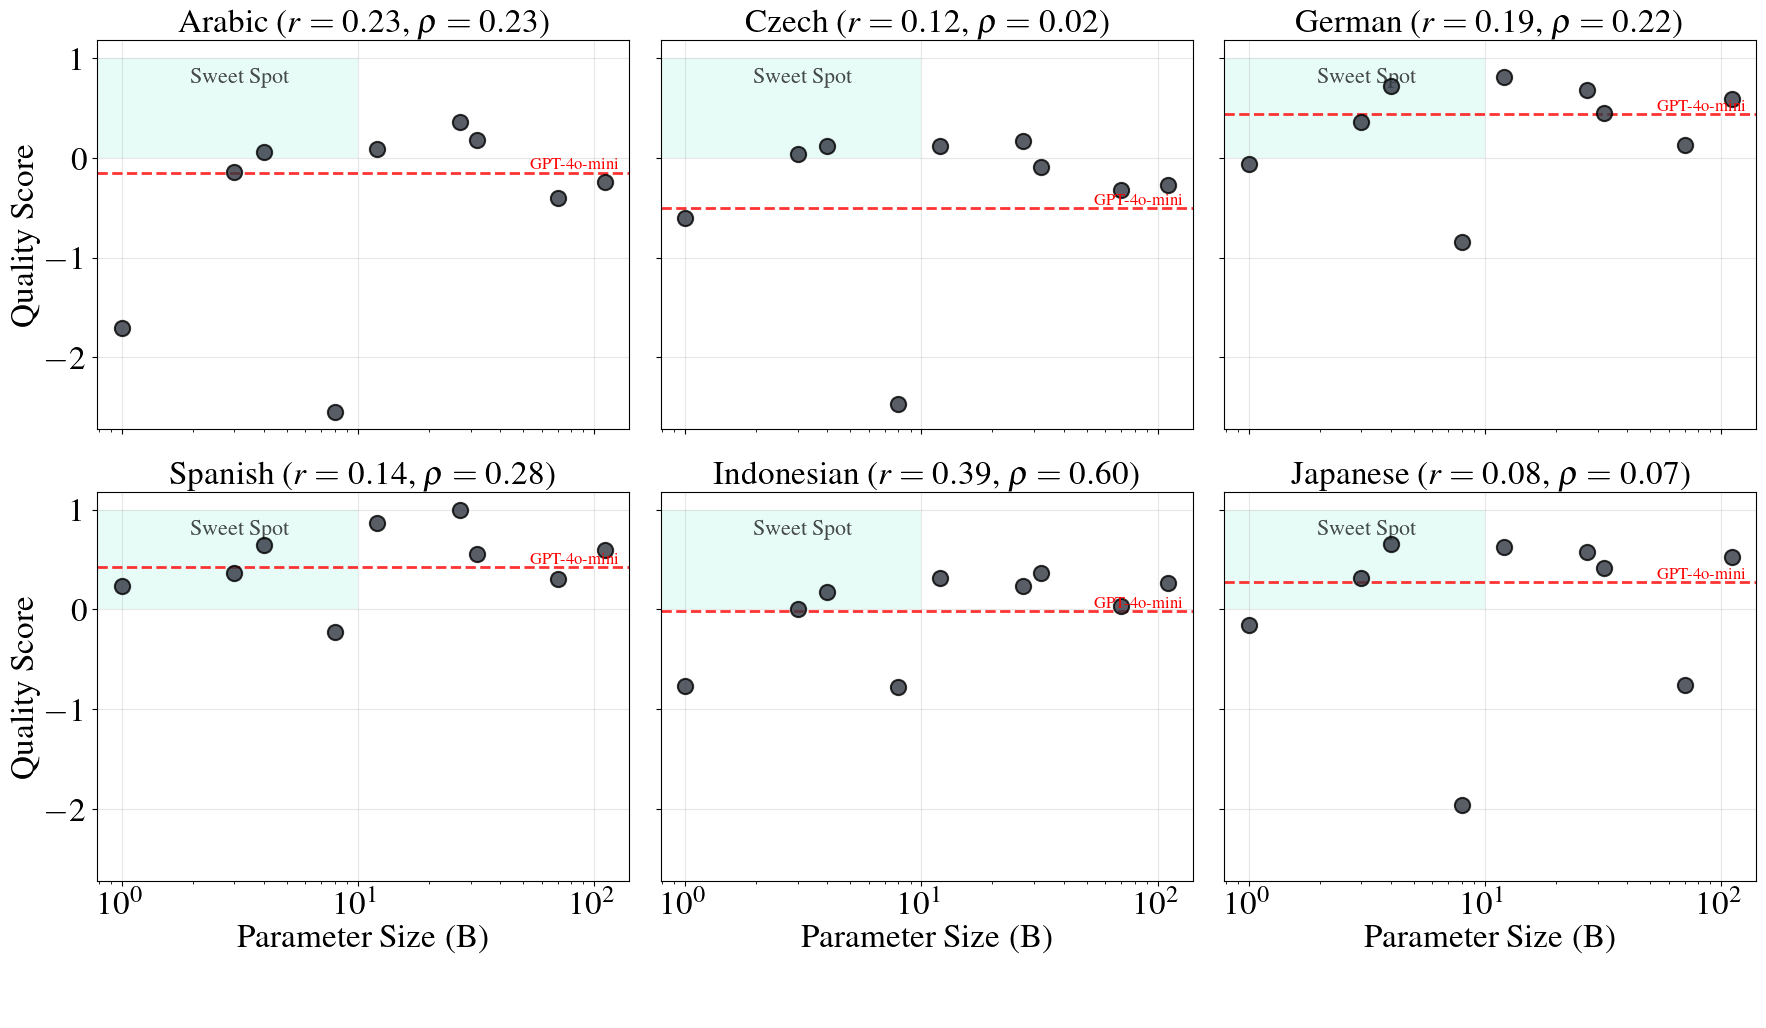

In [ ]:
# Merge model size information
model_info_df = pd.DataFrame([m.model_dump() for m in MODEL_INFORMATION])
df_with_size = df.merge(
    model_info_df[["name", "parameter_size", "model_family"]],
    left_on="model",
    right_on="name",
    how="left",
)

# Compute correlation for each language
from scipy.stats import pearsonr, spearmanr

correlations = {}
for lang in ["ar", "cs", "de", "es", "id", "ja"]:
    df_lang = df_with_size[df_with_size["language"] == lang]
    df_lang_plot = df_lang[df_lang["parameter_size"] != "Unknown"].copy()
    df_lang_plot["parameter_size"] = df_lang_plot["parameter_size"].astype(float)

    pearson_corr, pearson_p = pearsonr(
        df_lang_plot["parameter_size"], df_lang_plot["quality_score"]
    )
    spearman_corr, spearman_p = spearmanr(
        df_lang_plot["parameter_size"], df_lang_plot["quality_score"]
    )

    correlations[lang] = {
        "pearson": pearson_corr,
        "pearson_p": pearson_p,
        "spearman": spearman_corr,
        "spearman_p": spearman_p,
    }

# Download logos for model families
import urllib.request
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import io


def get_logo_for_family(family):
    """Get the logo URL for each model family"""
    logos = {
        "Aya": "https://cdn.prod.website-files.com/62902d243ad8aad5c0fb3e24/65d2db1ef79bc75bd0e6b41e_For-Cohere_-Logo-Assets-66.svg",
        "Command": "https://cdn.prod.website-files.com/62902d243ad8aad5c0fb3e24/65d2db1ef79bc75bd0e6b41e_For-Cohere_-Logo-Assets-66.svg",
        "Gemma": "https://www.gstatic.com/lamda/images/gemini_sparkle_v002_advanced_1743d7b7a7bc01f38e6f4.svg",
        "Granite": "https://www.ibm.com/brand/experience-guides/developer/b1db1ae501d522a1a4b49613fe07c9f1/01_8-bar-positive.svg",
        "Llama": "https://upload.wikimedia.org/wikipedia/commons/a/ab/Meta-Logo.png",
    }
    return logos.get(family)


def load_image_from_url(url, zoom=0.08):
    """Load an image from URL and return OffsetImage for matplotlib"""
    try:
        with urllib.request.urlopen(url, timeout=10) as response:
            image_data = response.read()

        # Load with PIL
        img = Image.open(io.BytesIO(image_data))

        # Convert SVG images or handle transparency
        if img.mode == "RGBA":
            # Create white background
            background = Image.new("RGBA", img.size, (255, 255, 255, 255))
            img = Image.alpha_composite(background, img)
            img = img.convert("RGB")
        elif img.mode != "RGB":
            img = img.convert("RGB")

        return OffsetImage(img, zoom=zoom)
    except Exception as e:
        print(f"Failed to load image from {url}: {e}")
        return None


# Pre-load all logos
print("Loading model family logos...")
logo_images = {}
for family in ["Aya", "Command", "Gemma", "Granite", "Llama"]:
    url = get_logo_for_family(family)
    if url:
        img = load_image_from_url(url)
        if img:
            logo_images[family] = img
            print(f"Loaded {family} logo")

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

languages = ["ar", "cs", "de", "es", "id", "ja"]
language_names = {
    "ar": "Arabic",
    "cs": "Czech",
    "de": "German",
    "es": "Spanish",
    "id": "Indonesian",
    "ja": "Japanese",
}

for idx, (lang, ax) in enumerate(zip(languages, axes)):
    df_lang = df_with_size[df_with_size["language"] == lang]
    df_lang_plot = df_lang[df_lang["parameter_size"] != "Unknown"].copy()
    df_lang_plot["parameter_size"] = df_lang_plot["parameter_size"].astype(float)

    gpt4o_mini_lang = df_lang[df_lang["model"] == "gpt-4o-mini-2024-07-18"]
    gpt4o_mini_quality_lang = gpt4o_mini_lang["quality_score"].iloc[0]

    # Add sweet spot highlight (upper left quadrant)
    from matplotlib.patches import Rectangle

    sweet_spot = Rectangle(
        (0, 0),  # (x, y) bottom left corner - start from 10^0 = 1
        10**1,  # width: from 1 to 10
        1,  # height: from 0 to 1
        facecolor=COLORS["blue"],
        edgecolor="none",
        alpha=0.5,
        zorder=0,
    )
    ax.add_patch(sweet_spot)

    # Add "Sweet Spot" label
    ax.text(
        10**0.5,  # center of x-range in log scale
        0.9,
        "Sweet Spot",
        fontsize=16,
        ha="center",
        va="top",
        color="black",
        weight="bold",
        alpha=0.7,
    )

    families = df_lang_plot["model_family"].unique()
    for family in families:
        family_data = df_lang_plot[df_lang_plot["model_family"] == family]

        # Plot logos as markers
        for _, row in family_data.iterrows():
            x_pos = row["parameter_size"]
            y_pos = row["quality_score"]

            if family in logo_images:
                # Add logo as image
                ab = AnnotationBbox(
                    logo_images[family],
                    (x_pos, y_pos),
                    frameon=False,
                    zorder=3,
                )
                ax.add_artist(ab)
            else:
                # Fallback to regular marker if logo failed to load
                ax.scatter(
                    x_pos,
                    y_pos,
                    color="#2E3440",
                    marker="o",
                    s=120,
                    alpha=0.8,
                    edgecolors="black",
                    linewidth=1.5,
                    zorder=3,
                )

        # Add invisible scatter for legend (only on last plot)
        if idx == 5 and family in logo_images:
            ax.scatter([], [], label=family, color="#2E3440", marker="s", s=120)

    # Add horizontal line for GPT-4o-mini
    ax.axhline(
        y=gpt4o_mini_quality_lang,
        color="red",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        zorder=2,
    )
    ax.text(
        0.98,
        gpt4o_mini_quality_lang,
        "GPT-4o-mini",
        transform=ax.get_yaxis_transform(),
        fontsize=12,
        color="red",
        va="bottom",
        ha="right",
    )

    pearson_corr = correlations[lang]["pearson"]
    spearman_corr = correlations[lang]["spearman"]
    ax.set_title(
        f"{language_names[lang]} ($r={pearson_corr:.2f}$, $\\rho={spearman_corr:.2f}$)"
    )
    if idx >= 3:  # Only show x-label for bottom row
        ax.set_xlabel("Parameter Size (B)")
    ax.set_xscale("log")
    if idx % 3 == 0:  # Only show y-label for leftmost column
        ax.set_ylabel("Quality Score")
    ax.grid(True, alpha=0.3, zorder=1)

fig.legend(
    *axes[5].get_legend_handles_labels(),
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    fontsize=21,
)

plt.tight_layout()
fig.savefig("figures/model_size_vs_quality_by_language.png", dpi=300, bbox_inches="tight")  # fmt: skip

plt.show()